# 시작

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install paddlepaddle paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.7/465.7 kB 39.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 53.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.2/299.2 kB 28.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 91.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 24.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.6/239.6 kB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━

# 라이브러리 호출

In [14]:
import os
import re
from itertools import combinations
from PIL import Image
import numpy as np
import cv2
from paddleocr import PaddleOCR, draw_ocr
import csv

import matplotlib.pyplot as plt
from IPython.display import display

In [4]:
# OCR 모델 초기화
ocr_model = PaddleOCR(use_angle_cls=True, lang='en')

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 4.00M/4.00M [00:08<00:00, 460kiB/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:18<00:00, 559kiB/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2.19M/2.19M [00:14<00:00, 148kiB/s]

[2024/03/21 07:32:06] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_char_dict_path='

# 설정

In [ ]:
# 이미지 로드
base_dir = '/content/drive/MyDrive/Projects/Lostark/data'
image_path = os.path.join(base_dir, 'image/Scarecrow/assasin_01(10fps)/frame0028.jpg')
original_image = Image.open(image_path)

# RGB 전처리 함수(preprocess_image)
target_rgb = (201, 180, 91) # 노란색, 크리티컬
# target_rgb = (253, 239, 238) # 흰색, 일반공격
tolerance = 50

# 전처리함수

In [5]:
# 전처리 함수들
def preprocess_image(image, target_rgb, tolerance):
    if image.mode != 'RGB':
        return image

    pixels = image.load()
    new_image = Image.new('RGB', image.size)
    new_pixels = new_image.load()

    for i in range(image.width):
        for j in range(image.height):
            r, g, b = pixels[i, j]
            if target_rgb[0] - tolerance <= r <= target_rgb[0] + tolerance and \
               target_rgb[1] - tolerance <= g <= target_rgb[1] + tolerance and \
               target_rgb[2] - tolerance <= b <= target_rgb[2] + tolerance:
                new_pixels[i, j] = (r, g, b)
            else:
                new_pixels[i, j] = (0, 0, 0)
    return new_image

# 에지 검출
def edge_detection(image):
    image_np = np.array(image)

    if image_np.ndim == 3 and image_np.shape[2] == 3:
        gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_np
    edges = cv2.Canny(gray, 100, 200)
    return Image.fromarray(edges)

# 이진화
def binarization(image):
    image_np = np.array(image)

    if image_np.ndim == 3 and image_np.shape[2] == 3:
        gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_np
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return Image.fromarray(binary)

# 잡음 제거
def denoising(image):
    img = cv2.GaussianBlur(np.array(image), (5, 5), 0)
    return Image.fromarray(img)

# 형태학 연산
def morphological_operations(image):
    kernel = np.ones((3, 3), np.uint8)
    img = cv2.morphologyEx(np.array(image), cv2.MORPH_OPEN, kernel)
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    return Image.fromarray(img)

# 윤곽선 검출
def contour_detection(image):
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img = np.zeros_like(gray)
    cv2.drawContours(img, contours, -1, 255, 3)
    return Image.fromarray(img)

# 투영 프로파일
def projection_profile(image):
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    projection = cv2.reduce(binary, 1, cv2.REDUCE_AVG).reshape(-1)
    coord = np.column_stack(np.where(projection > 0))
    img = np.zeros_like(gray)
    for x1, y1 in coord:
        cv2.line(img, (x1, y1), (x1, y1), 255, 1)
    return Image.fromarray(img)

# OCR 함수

In [33]:
# OCR 함수
def extract_text_with_ocr(image):
    try:
        image_np = np.array(image)
        if image_np.ndim == 2:
            image_np = cv2.cvtColor(image_np, cv2.COLOR_GRAY2BGR)
        elif image_np.ndim == 3 and image_np.shape[2] == 4:
            image_np = cv2.cvtColor(image_np, cv2.COLOR_RGBA2BGR)

        ocr_result = ocr_model.ocr(image_np)
        ocr_text = ''
        for line in ocr_result[0]:
            text = line[1][0]
            score = line[1][1]
            if re.match(r'^[\d,\.]+$', text): # , 와 . 를 포함한 숫자만 남기고 제거
                ocr_text += f"{text}, {score:.2f} "
        return ocr_text, ocr_result
    except Exception as e:
        print(f"OCR error occurred: {str(e)}")
        return '', []  # 예외 발생 시 빈 문자열과 빈 리스트 반환

# 바운딩 박스 시각화 함수

In [38]:
# 바운딩박스 시각화 함수
def visualize_ocr_result(image, ocr_result):
    try:
        image_np = np.array(image)
        if image_np.ndim == 2:
            image_rgb = cv2.cvtColor(image_np, cv2.COLOR_GRAY2RGB)
        elif image_np.ndim == 3 and image_np.shape[2] == 4:
            image_rgb = cv2.cvtColor(image_np, cv2.COLOR_RGBA2RGB)
        else:
            image_rgb = image_np

        for line in ocr_result[0]:
            box = line[0]
            text = line[1][0]
            score = line[1][1]
            pts = np.array(box, np.int32).reshape((-1, 1, 2))
            cv2.polylines(image_rgb, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
            cv2.putText(image_rgb, f"{text}, {score:.2f}", (pts[0][0][0], pts[0][0][1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        return Image.fromarray(image_rgb)
    except Exception as e:
        print(f"Visualization error occurred: {str(e)}")
        return None

# 이미지 크기 조절 함수
def resize_image(image, max_width, max_height):
    width, height = image.size
    ratio = min(max_width / width, max_height / height)
    new_width = int(width * ratio)
    new_height = int(height * ratio)
    resized_image = image.resize((new_width, new_height), Image.ANTIALIAS)
    return resized_image

# 전처리 조합

전처리 함수 목록:
1. preprocess_image
2. edge_detection
3. binarization
4. denoising
5. morphological_operations
6. contour_detection
7. projection_profile
원하는 전처리 함수의 번호를 입력하세요 (쉼표로 구분, 순서대로 입력): 4
전처리된 이미지:


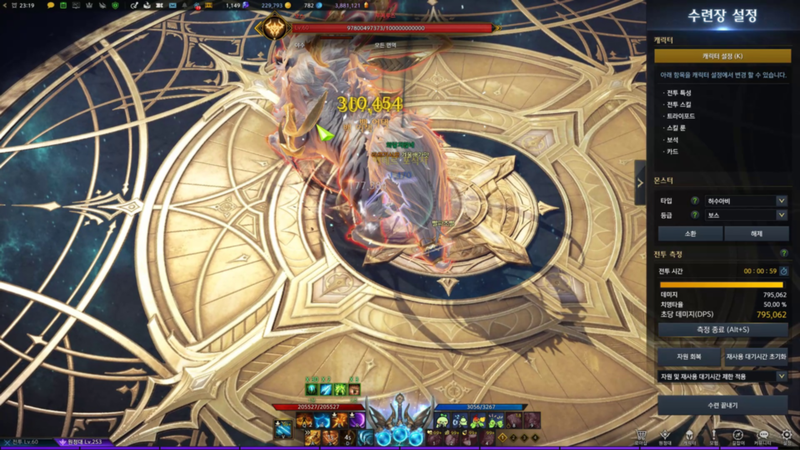

[2024/03/21 08:03:35] ppocr DEBUG: dt_boxes num : 48, elapsed : 0.1920769214630127
[2024/03/21 08:03:35] ppocr DEBUG: cls num  : 48, elapsed : 0.11340188980102539
[2024/03/21 08:03:37] ppocr DEBUG: rec_res num  : 48, elapsed : 2.1726691722869873
OCR 텍스트: 229.793, 0.95 300,454, 0.94 13, 0.59 795,062, 0.95 795,062, 0.98 
바운딩 박스 이미지:


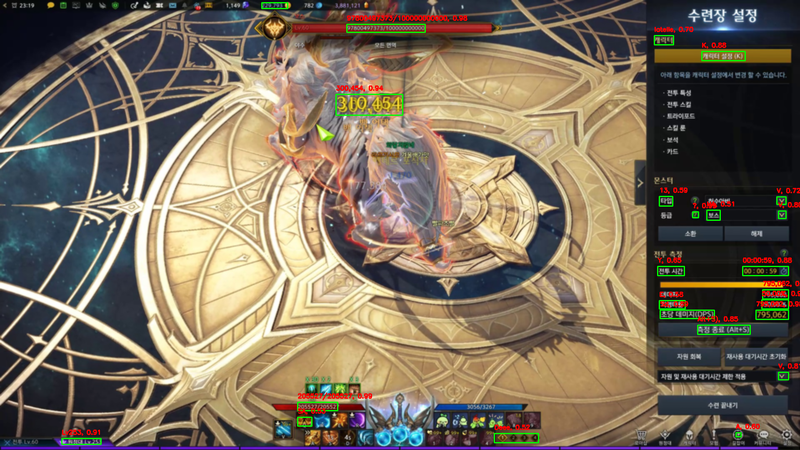

In [39]:
# 전처리 함수 목록
preprocess_functions = [
    preprocess_image,
    edge_detection,
    binarization,
    denoising,
    morphological_operations,
    contour_detection,
    projection_profile
]

# 전처리 함수 이름 출력
print("전처리 함수 목록:")
for i, func in enumerate(preprocess_functions):
    print(f"{i + 1}. {func.__name__}")

# 사용자로부터 전처리 함수 선택 및 순서 입력 받기
selected_indices = input("원하는 전처리 함수의 번호를 입력하세요 (쉼표로 구분, 순서대로 입력): ").split(',')
selected_indices = [int(idx.strip()) for idx in selected_indices]

selected_functions = [preprocess_functions[idx - 1] for idx in selected_indices]


# 선택된 전처리 함수 순서대로 적용
processed_image = original_image.copy()
for func in selected_functions:
    if func == preprocess_image:
        processed_image = func(processed_image, target_rgb, tolerance)
    else:
        processed_image = func(processed_image)

# 전처리된 이미지 출력
print("전처리된 이미지:")
max_width, max_height = 800, 600  # 원하는 최대 크기로 설정
resized_processed_image = resize_image(processed_image, max_width, max_height)
display(resized_processed_image)

# OCR 수행
ocr_text, ocr_result = extract_text_with_ocr(processed_image_np)
print(f"OCR 텍스트: {ocr_text}")

# 바운딩 박스 시각화
visualized_image = visualize_ocr_result(processed_image_np, ocr_result)
if visualized_image is not None:
    print("바운딩 박스 이미지:")
    resized_visualized_image = resize_image(visualized_image, max_width, max_height)
    display(resized_visualized_image)
else:
    print("바운딩 박스 이미지 생성 실패.")